<!--
  ============================================================================
  negativebinomial_simulations.ipynb  —  reproducibility notebook
  Section M.2 of the Supplementary Materials
  ============================================================================
-->

<h1 align="center">Negative-Binomial Type II SSG Likelihood Simulations</h1>

<p align="center">
  <b>Reproducibility for Experiments E1 and E2 and the ELBO trajectories of Section M.2 of the Supplementary Materials</b><br>
  <i>TAVIE-SSG vs. ADVI (mean-field &amp; full-rank) &middot; DADVI &middot; PyMC (NUTS)</i>
</p>

<p align="center">
  <img alt="Python" src="https://img.shields.io/badge/Python-3.9-3776AB?logo=python&logoColor=white">
  <img alt="Jupyter" src="https://img.shields.io/badge/Jupyter-Notebook-F37626?logo=jupyter&logoColor=white">
  <img alt="PyMC" src="https://img.shields.io/badge/PyMC-5.x-1E4C7E">
  <img alt="JAX" src="https://img.shields.io/badge/JAX-x64-8A2BE2">
</p>

<p align="center">
  <a href="https://github.com/Roy-SR-007/TAVIE-SSG/blob/main/negative-binomial_simulations.ipynb"><img alt="nbviewer" src="https://img.shields.io/badge/render-nbviewer-F37726?logo=jupyter&logoColor=white"></a>
  <img alt="Data" src="https://img.shields.io/badge/data-simulated-005EA2">
</p>

---

### What this notebook does

This notebook comprises the Negative-Binomial Type II SSG likelihood experiments, namely

1. Experiments **E1** and **E2** in Section M.2 of the Supplementary Materials — MSEs of
   the parameter estimates, runtimes, and sliced-Wasserstein distances;
2. the **ELBO trajectory** plots, also in Section M.2 of the Supplementary Materials.

Data are simulated from a Negative-Binomial regression with known $r$, and **TAVIE-SSG**
is compared against four competitors over independent replicates.

| | Specification |
|:--|:--|
| **Model** | $y \sim \mathrm{NB}\!\left(r,\ p = \mathrm{sigmoid}(X\boldsymbol\beta)\right)$, equivalently $\mu = r\exp(-X\boldsymbol\beta)$ |
| **Priors** | $\boldsymbol\beta \sim \mathcal{N}(0, 1)$ |
| **Truth** | $r = 10$ known, $\boldsymbol\beta_{0}$ drawn from $\mathcal{N}(0, 1)$ |
| **Experiment E1** | fixed $p = 9$, $n \in \{200, 500, 1000, 2000\}$, 100 replicates |
| **Experiment E2** | fixed $n = 1000$, $p \in \{4, 9, 16, 21\}$, 100 replicates |
| **Methods** | TAVIE-SSG, ADVI (MF), ADVI (FR), DADVI, PyMC (NUTS) |
| **Metrics** | $p^{-1}\lVert \boldsymbol\beta_0 - \hat{\boldsymbol\beta}\rVert_{2}^{2}$, wall-clock runtime, and sliced-Wasserstein distance to the PyMC (NUTS) posterior |

> [!IMPORTANT]
> **To reproduce, run every cell in order, top to bottom.**

### Results generated in this notebook

| Main Manuscript | Supplementary Materials | Output file |
|:--:|:--:|:--|
| — | **Figure 28** | `Neg-Bin_MSE_boxplots_multi_n_p_8.pdf` |
| — | **Figure 29** | `Negbin_SW_boxplots_multi_n_p_8_logscale.pdf` |
| — | **Figure 30** | `Neg-Bin_MSE_boxplots_multi_p_n_1000.pdf` |
| — | **Figure 31** | `runtime_Negbin_multi_n_multi_p.pdf` |
| — | **Figure 32** | `NegBin_ELBO_n_1000_p_8.pdf` |

All figures are written to `results_compete/plots/`, and the intermediate result files to
`results_compete/`.

### Required Imports for TAVIE-SSG and Competitors

In [ ]:
# imports required
# setup the dadvi module following https://github.com/martiningram/dadvi
import pymc as pm
import pytensor
import pytensor.tensor as pt
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import jax
import jax.numpy as jnp
setattr(jnp, "product", jnp.prod)
jax.config.update("jax_enable_x64", True)
from CompetingMethods import *
from dadvi.pymc.jax_api import fit_pymc_dadvi_with_jax
from TAVIE import *
import rich
from sklearn.preprocessing import scale
from IPython.display import display, Latex
from time import perf_counter
from tqdm import tqdm, trange
from scipy.stats import t
import arviz as az
import re

### Negative-Binomial PyMC model and NUTS

In [ ]:
def negbin_pymc_model(X, y, r):
    """
    Negative Binomial regression:
        y ~ NB(n=r, p = sigmoid(X @ beta))
    which is equivalent to mean mu = r * exp(-X @ beta).

    r: float or array-like of length n. If float, it's broadcast to length n.
    """
    # ensure arrays & shapes
    X = np.asarray(X)
    y = np.asarray(y)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    n, p = X.shape

    # counts must be non-negative integers
    if not np.issubdtype(y.dtype, np.integer):
        y = y.astype(np.int64)

    # handle r: float -> length-n vector; array -> validate length
    if np.isscalar(r):
        r_vec = np.full(n, float(r))
    else:
        r_vec = np.asarray(r, dtype=float).reshape(-1)
        if r_vec.size != n:
            raise ValueError(f"r must be scalar or length n={n}, got {r_vec.size}")
    if np.any(r_vec <= 0):
        raise ValueError("All entries of r must be > 0")

    fxdtype = np.dtype(pytensor.config.floatX)

    with pm.Model() as model:
        # data
        X_data = pm.MutableData("X", X.astype(fxdtype))
        y_data = pm.MutableData("y", y)
        r_data = pm.MutableData("r", r_vec.astype(fxdtype))

        # prior on beta
        beta = pm.Normal("beta", mu=0.0, sigma=1.0, shape=p)

        # linear predictor & link
        eta = pt.dot(X_data, beta)                 # shape (n,)
        p_nb = pm.math.sigmoid(eta)                # p in (0,1)
        mu   = pm.Deterministic("mu", r_data * pt.exp(-eta))  # for inspection

        # NB likelihood with (n=r, p=sigmoid(Xβ))
        pm.NegativeBinomial("y_obs", n=r_data, p=p_nb, observed=y_data)

    return model


def fit_NUTS_negbin(model):
    """
    Fit the NB model (with known r) using NUTS and return posterior means for beta.
    """
    import logging, warnings
    logging.getLogger("pymc").setLevel(logging.ERROR)
    logging.getLogger("pytensor").setLevel(logging.ERROR)
    warnings.filterwarnings("ignore", message=r"os\.fork\(\) was called", category=RuntimeWarning)

    with model:
        idata = pm.sample(progressbar=False, compute_convergence_checks=False)

    summ = az.summary(idata, var_names=["beta"])[["mean"]]

    # beta mean (scalar or vector)
    beta_rows = summ[summ.index.str.startswith("beta")]
    if len(beta_rows) == 1 and beta_rows.index[0] == "beta":
        beta_mean = float(beta_rows["mean"].iloc[0])
    else:
        def _idx(name):
            m = re.match(r"beta\[(\d+)\]", name)
            return int(m.group(1)) if m else 0
        beta_mean = (
            beta_rows.assign(_i=beta_rows.index.map(_idx))
                     .sort_values("_i")["mean"]
                     .to_numpy()
        )

    return {"beta": np.array(beta_mean)}


### Experiment E1: fixed $p=9$ (includes intercept) and $n\in \{200, 500, 1000, 2000\}$

Recording $p^{-1}\lVert \beta_0 - \hat{\beta}\rVert_{2}^{2}$. The results are stored in `results_compete/NegBin_metrics_multi_n_p_8.pkl`.

In [ ]:
# ==== Experiment settings ====
total_p = 9  # total_p = p + 1
p = 8
num_reps = 100
r = 10
sample_sizes = [200, 500, 1000, 2000]     # <-- your various n’s here

# True beta vector
beta_true = np.random.normal(loc=0.0, scale=0.5, size=p+1)

# Prior for full‐cov BBVI
Sigma_prior = np.eye(p + 1)

# Pre‐allocate storage: shape (len(sample_sizes), num_reps)
n_sizes = len(sample_sizes)
mse_beta_TAVIE          = np.zeros((n_sizes, num_reps))
time_TAVIE              = np.zeros((n_sizes, num_reps))

mse_beta_DADVI          = np.zeros((n_sizes, num_reps))
time_DADVI              = np.zeros((n_sizes, num_reps))

mse_beta_NUTS          = np.zeros((n_sizes, num_reps))
time_NUTS              = np.zeros((n_sizes, num_reps))

mse_beta_ADVI_mf           = np.zeros((n_sizes, num_reps))
time_ADVI_mf               = np.zeros((n_sizes, num_reps))

mse_beta_ADVI_fr   = np.zeros((n_sizes, num_reps))
time_ADVI_fr       = np.zeros((n_sizes, num_reps))

# TAVIE model initialization
negbin_tavie_model = TAVIE_type_II(family="negbin", fit_intercept=True)

# ==== Main loops ====
for i, n in enumerate(sample_sizes):
    for rep in trange(num_reps, desc=f"n={n}"):
        np.random.seed(rep)
        # Generate synthetic data
        X = np.random.normal(size=(n, p))
        X_bbvi = np.column_stack((np.ones(n), X))
        linear_term  = beta_true[0] + X @ beta_true[1:len(beta_true)] 
        probs = 1 / (1 + np.exp(-linear_term))
        y = np.random.negative_binomial(r, probs, size=n)

        # ---- TAVIE ----
        t0 = perf_counter()
        negbin_tavie_model.fit(X, y, r=r, verbose=False)
        time_TAVIE[i, rep] = perf_counter() - t0
        beta_est_TAVIE = negbin_tavie_model.get_TAVIE_means(verbose=False)
        mse_beta_TAVIE[i, rep] = np.mean((beta_est_TAVIE - beta_true)**2)


        # DADVI estimator
        negbin_dadvi_model = negbin_pymc_model(X_bbvi, y, r=r)
        t0 = perf_counter()
        negbin_dadvi_res = fit_pymc_dadvi_with_jax(negbin_dadvi_model, num_fixed_draws=30).get_posterior_means()
        time_DADVI[i, rep] = perf_counter() - t0
        beta_est_DADVI = negbin_dadvi_res['beta']
        mse_beta_DADVI[i, rep] = np.mean((beta_est_DADVI - beta_true)**2)
    
        # NUTS estimator
        t0 = perf_counter()
        negbin_nuts_res = fit_NUTS_negbin(negbin_dadvi_model)
        time_NUTS[i, rep] = perf_counter() - t0
        beta_est_NUTS = negbin_nuts_res['beta']
        mse_beta_NUTS[i, rep] = np.mean((beta_est_NUTS - beta_true)**2)

        # ADVI mean-field estimator
        t0 = perf_counter()
        res2 = BBVI_NegBin_patience_best(X_bbvi, y, r=r, lr=1e-3, tol=1e-9, patience=1e4, verbose=False)
        time_ADVI_mf[i, rep] = perf_counter() - t0
        beta_est_ADVI_mf = res2['beta_mean']
        mse_beta_ADVI_mf[i, rep] = np.mean((beta_est_ADVI_mf - beta_true)**2)
    
        # ADVI full-rank estimator
        t0 = perf_counter()
        res3 = BBVI_NegBin_fullcov_AdamW_best(X_bbvi, y, r=r, Sigma_prior=Sigma_prior, lr=1e-3, tol=1e-9, patience=1e4, verbose=False)
        time_ADVI_fr[i, rep] = perf_counter() - t0
        beta_est_ADVI_fr = res3['beta_mean']
        mse_beta_ADVI_fr[i, rep] = np.mean((beta_est_ADVI_fr - beta_true)**2)

# saving the metrics
import pickle

# collect everything into a single dict
metrics_df = {
    'p'            :       p,
    'n'            :       sample_sizes,
    'mse_beta_TAVIE':     mse_beta_TAVIE,
    'time_TAVIE':         time_TAVIE,
    'mse_beta_ADVI_mf':      mse_beta_ADVI_mf,
    'time_ADVI_mf':          time_ADVI_mf,
    'mse_beta_ADVI_fr':      mse_beta_ADVI_fr,
    'time_ADVI_fr':          time_ADVI_fr,
    'mse_beta_DADVI':      mse_beta_DADVI,
    'time_DADVI':          time_DADVI,
    'mse_beta_NUTS':      mse_beta_NUTS,
    'time_NUTS':          time_NUTS,
}

# write to disk
with open(f'results_compete/NegBin_metrics_multi_n_p_{p}.pkl', 'wb') as f:
    pickle.dump(metrics_df, f, protocol=pickle.HIGHEST_PROTOCOL)

### Under Experiment E1, SW distance for Negative-Binomial Type II SSG likelihood

SW distance between PyMC (NUTS) approximation of the true posterior and TAVIE-SSG/ADVI (MF)/ADVI (FR)/DADVI. Results are in `results_compete/sw_negbin_compare_methods_1.0_p_8.csv` and `results_compete/sw_negbin_compare_methods_1.0_p_8.pkl`.

In [2]:
# required imports

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import perf_counter
from tqdm.auto import trange
import pymc as pm
import pytensor
import pytensor.tensor as pt
from matplotlib.patches import Patch
import jax
import jax.numpy as jnp
setattr(jnp, "product", jnp.prod)
jax.config.update("jax_enable_x64", True)
from CompetingMethods import *
from dadvi.pymc.jax_api import fit_pymc_dadvi_with_jax
from TAVIE import *
import rich
from sklearn.preprocessing import scale
from IPython.display import display, Latex
from time import perf_counter
from tqdm import tqdm, trange
from scipy.stats import t
import arviz as az
import re

In [ ]:
# ============================================================
# SETTINGS
# ============================================================
total_p = 9  # total_p = p + 1
p = 8
r = 10
alpha = 1.0

num_reps = 10
sample_sizes = [200, 500, 1000, 2000]

Sigma_prior = np.eye(p + 1)

nuts_draws = 4000
nuts_tune = 1000
nuts_chains = 2
nuts_target_accept = 0.9
n_proj = 500

output_dir = "results_compete"
os.makedirs(output_dir, exist_ok=True)

np.random.seed(123)
beta_true = np.random.normal(loc=0.0, scale=0.5, size=p + 1)


# ============================================================
# DATA GENERATION
# ============================================================
def generate_negbin_regression_data(n, p, beta_true, r, seed=None):
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n, p))
    linear_term = beta_true[0] + X @ beta_true[1:]
    probs = 1.0 / (1.0 + np.exp(-linear_term))
    y = rng.negative_binomial(r, probs, size=n)
    return X, y


# ============================================================
# PYMC MODEL: Negative-Binomial posterior over beta
# z = beta
# ============================================================
def negbin_fractional_pymc_model(X, y, r, alpha=1.0, prior_var=1.0):
    X = np.asarray(X)
    y = np.asarray(y)

    if X.ndim == 1:
        X = X.reshape(-1, 1)

    n_local, p_local = X.shape
    X_with_intercept = np.column_stack((np.ones(n_local), X))

    dtype = np.dtype(pytensor.config.floatX)
    X_with_intercept = X_with_intercept.astype(dtype)
    y = y.astype(dtype)

    with pm.Model() as model:
        X_data = pm.Data("X_data", X_with_intercept)
        y_data = pm.Data("y_data", y)

        beta = pm.Normal("beta", mu=0.0, sigma=np.sqrt(prior_var), shape=p_local + 1)

        eta = pt.dot(X_data, beta)
        p_prob = pm.math.sigmoid(eta)

        loglik_vec = pm.logp(pm.NegativeBinomial.dist(n=r, p=p_prob), y_data)
        pm.Potential("frac_loglik", alpha * pt.sum(loglik_vec))

    return model


def negbin_fractional_pymc_model_with_intercept_design(X_bbvi, y, r, alpha=1.0, prior_var=1.0):
    X_bbvi = np.asarray(X_bbvi)
    y = np.asarray(y)

    dtype = np.dtype(pytensor.config.floatX)
    X_bbvi = X_bbvi.astype(dtype)
    y = y.astype(dtype)

    n_local, p1 = X_bbvi.shape

    with pm.Model() as model:
        X_data = pm.Data("X_data", X_bbvi)
        y_data = pm.Data("y_data", y)

        beta = pm.Normal("beta", mu=0.0, sigma=np.sqrt(prior_var), shape=p1)

        eta = pt.dot(X_data, beta)
        p_prob = pm.math.sigmoid(eta)

        loglik_vec = pm.logp(pm.NegativeBinomial.dist(n=r, p=p_prob), y_data)
        pm.Potential("frac_loglik", alpha * pt.sum(loglik_vec))

    return model


def fit_NUTS_negbin_fractional(
    model,
    draws=4000,
    tune=1000,
    chains=2,
    target_accept=0.9,
    random_seed=123
):
    with model:
        idata = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            cores=1,
            target_accept=target_accept,
            progressbar=False,
            compute_convergence_checks=False,
            random_seed=random_seed,
            return_inferencedata=True
        )
    return idata


def extract_true_beta_samples(idata):
    beta_draws = idata.posterior["beta"].stack(sample=("chain", "draw")).values
    if beta_draws.shape[0] < beta_draws.shape[1]:
        beta_draws = beta_draws.T
    return np.asarray(beta_draws, dtype=float)


# ============================================================
# SLICED WASSERSTEIN
# ============================================================
def wasserstein_1d_sorted(x, y):
    x = np.sort(np.asarray(x, dtype=float))
    y = np.sort(np.asarray(y, dtype=float))

    m = min(len(x), len(y))
    if len(x) != len(y):
        q = (np.arange(m) + 0.5) / m
        x = np.quantile(x, q)
        y = np.quantile(y, q)

    return np.mean(np.abs(x - y))


def sliced_wasserstein_distance(X, Y, n_proj=500, seed=123):
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)

    d = X.shape[1]
    rng = np.random.default_rng(seed)

    dirs = rng.normal(size=(n_proj, d))
    dirs /= np.linalg.norm(dirs, axis=1, keepdims=True)

    sw_vals = np.empty(n_proj, dtype=float)
    for j in range(n_proj):
        v = dirs[j]
        sw_vals[j] = wasserstein_1d_sorted(X @ v, Y @ v)

    return float(np.mean(sw_vals))


# ============================================================
# TAVIE: Negative-Binomial
# Need posterior hyperparameters from get_variational_estimates()
# ============================================================
def fit_tavie_negbin_and_sample_beta(X, y, r, alpha, n_samples, seed=123):
    model = TAVIE_type_II(family="negbin", fit_intercept=True)
    model.fit(X, y, r=r, alpha=alpha, verbose=False)

    ve = model.get_variational_estimates()

    # expected keys for Gaussian variational posterior over beta
    if "m_xi" in ve and "V_xi" in ve:
        mean_beta = np.asarray(ve["m_xi"], dtype=float)
        cov_beta = np.asarray(ve["V_xi"], dtype=float)
    elif "m" in ve and "V" in ve:
        mean_beta = np.asarray(ve["m"], dtype=float)
        cov_beta = np.asarray(ve["V"], dtype=float)
    else:
        raise ValueError(
            "TAVIE_type_II.get_variational_estimates() did not expose Gaussian "
            "mean/covariance for beta. Please adjust fit_tavie_negbin_and_sample_beta."
        )

    cov_beta = 0.5 * (cov_beta + cov_beta.T)
    rng = np.random.default_rng(seed)
    beta_draws = rng.multivariate_normal(mean=mean_beta, cov=cov_beta, size=n_samples)
    return beta_draws


def sample_negbin_advi_mf_beta(q_mu, q_sd, n_samples, seed=123):
    rng = np.random.default_rng(seed)
    q_mu = np.asarray(q_mu, dtype=float).reshape(-1)
    q_sd = np.asarray(q_sd, dtype=float).reshape(-1)
    return q_mu[None, :] + rng.normal(size=(n_samples, len(q_mu))) * q_sd[None, :]


def fit_negbin_advi_mf_and_sample_beta(X_bbvi, y, r, n_samples, seed=123):
    res = BBVI_NegBin_patience_best(
        X=X_bbvi, y=y, r=r,
        num_iters=10000, lr=1e-3, tol=1e-8, patience=500,
        weight_decay=1e-2, verbose=False
    )
    beta_draws = sample_negbin_advi_mf_beta(res["q_mu"], res["q_sd"], n_samples=n_samples, seed=seed)
    return beta_draws, res


def sample_negbin_advi_fr_beta(q_mu, q_L, n_samples, seed=123):
    rng = np.random.default_rng(seed)
    q_mu = np.asarray(q_mu, dtype=float).reshape(-1)
    q_L = np.asarray(q_L, dtype=float)
    eps = rng.normal(size=(n_samples, len(q_mu)))
    return q_mu[None, :] + eps @ q_L.T


def fit_negbin_advi_fr_and_sample_beta(X_bbvi, y, r, Sigma_prior, n_samples, seed=123):
    res = BBVI_NegBin_fullcov_AdamW_best(
        X=X_bbvi, y=y, r=r, Sigma_prior=Sigma_prior,
        num_iters=20000, lr=1e-3, tol=1e-8, patience=1000,
        weight_decay=1e-2, verbose=False
    )
    beta_draws = sample_negbin_advi_fr_beta(res["q_mu"], res["q_L"], n_samples=n_samples, seed=seed)
    return beta_draws, res


# ============================================================
# DADVI: Negative-Binomial
# ============================================================
def fit_negbin_dadvi_and_sample_beta(pymc_model, n_samples, seed=123):
    dadvi_fit = fit_pymc_dadvi_with_jax(
        pymc_model,
        num_fixed_draws=30,
        seed=seed
    )

    dadvi_draws = dadvi_fit.get_posterior_draws_mean_field(
        n_draws=n_samples,
        seed=seed + 17
    )

    beta_draws = np.asarray(dadvi_draws["beta"], dtype=float)
    if beta_draws.ndim == 1:
        beta_draws = beta_draws.reshape(-1, 1)
    return beta_draws


# ============================================================
# ONE REPLICATION
# ============================================================
def run_one_replication_negbin(
    n, rep, beta_true, p, r, alpha,
    nuts_draws=4000, nuts_tune=1000, nuts_chains=2, target_accept=0.9,
    n_proj=500
):
    seed_base = 1000 + 37 * rep + 101 * n

    X, y = generate_negbin_regression_data(
        n=n, p=p, beta_true=beta_true, r=r, seed=seed_base
    )
    X_bbvi = np.column_stack([np.ones(n), X])

    # true posterior
    pymc_model = negbin_fractional_pymc_model(
        X=X, y=y, r=r, alpha=alpha, prior_var=1.0
    )

    t0 = perf_counter()
    idata = fit_NUTS_negbin_fractional(
        pymc_model,
        draws=nuts_draws, tune=nuts_tune, chains=nuts_chains,
        target_accept=target_accept, random_seed=seed_base
    )
    time_nuts = perf_counter() - t0

    beta_true_draws = extract_true_beta_samples(idata)
    n_samples = beta_true_draws.shape[0]

    # TAVIE
    t0 = perf_counter()
    beta_tavie_draws = fit_tavie_negbin_and_sample_beta(
        X=X, y=y, r=r, alpha=alpha, n_samples=n_samples, seed=seed_base + 1
    )
    time_tavie = perf_counter() - t0
    sw_tavie = sliced_wasserstein_distance(beta_true_draws, beta_tavie_draws, n_proj=n_proj, seed=seed_base + 101)

    # ADVI MF
    t0 = perf_counter()
    beta_advi_mf_draws, _ = fit_negbin_advi_mf_and_sample_beta(
        X_bbvi=X_bbvi, y=y, r=r, n_samples=n_samples, seed=seed_base + 2
    )
    time_advi_mf = perf_counter() - t0
    sw_advi_mf = sliced_wasserstein_distance(beta_true_draws, beta_advi_mf_draws, n_proj=n_proj, seed=seed_base + 102)

    # ADVI FR
    t0 = perf_counter()
    beta_advi_fr_draws, _ = fit_negbin_advi_fr_and_sample_beta(
        X_bbvi=X_bbvi, y=y, r=r, Sigma_prior=Sigma_prior, n_samples=n_samples, seed=seed_base + 3
    )
    time_advi_fr = perf_counter() - t0
    sw_advi_fr = sliced_wasserstein_distance(beta_true_draws, beta_advi_fr_draws, n_proj=n_proj, seed=seed_base + 103)

    # DADVI
    negbin_dadvi_model = negbin_fractional_pymc_model_with_intercept_design(
        X_bbvi=X_bbvi, y=y, r=r, alpha=alpha, prior_var=1.0
    )

    t0 = perf_counter()
    beta_dadvi_draws = fit_negbin_dadvi_and_sample_beta(
        pymc_model=negbin_dadvi_model, n_samples=n_samples, seed=seed_base + 4
    )
    time_dadvi = perf_counter() - t0
    sw_dadvi = sliced_wasserstein_distance(beta_true_draws, beta_dadvi_draws, n_proj=n_proj, seed=seed_base + 104)

    return {
        "n": n,
        "rep": rep,
        "alpha": alpha,
        "r": r,
        "sw_TAVIE": sw_tavie,
        "sw_ADVI_mf": sw_advi_mf,
        "sw_ADVI_fr": sw_advi_fr,
        "sw_DADVI": sw_dadvi,
        "time_NUTS": time_nuts,
        "time_TAVIE": time_tavie,
        "time_ADVI_mf": time_advi_mf,
        "time_ADVI_fr": time_advi_fr,
        "time_DADVI": time_dadvi,
        "num_true_samples": n_samples,
    }


# ============================================================
# RUN EXPERIMENT
# ============================================================
records = []

for n in sample_sizes:
    print(f"\nRunning n = {n}")
    for rep in trange(1, num_reps + 1, desc=f"n={n}"):
        out = run_one_replication_negbin(
            n=n,
            rep=rep,
            beta_true=beta_true,
            p=p,
            r=r,
            alpha=alpha,
            nuts_draws=nuts_draws,
            nuts_tune=nuts_tune,
            nuts_chains=nuts_chains,
            target_accept=nuts_target_accept,
            n_proj=n_proj
        )
        records.append(out)

results_df = pd.DataFrame(records)
results_df.to_csv(os.path.join(output_dir, f"sw_negbin_compare_methods_alpha_{alpha}_p_{p}.csv"), index=False)

with open(os.path.join(output_dir, f"sw_negbin_compare_methods_alpha_{alpha}_p_{p}.pkl"), "wb") as f:
    pickle.dump(records, f, protocol=pickle.HIGHEST_PROTOCOL)
    

plot_df = results_df.melt(
    id_vars=["n", "rep", "alpha"],
    value_vars=["sw_TAVIE", "sw_ADVI_mf", "sw_ADVI_fr", "sw_DADVI"],
    var_name="method",
    value_name="sliced_wasserstein"
)

plot_df["method"] = plot_df["method"].map({
    "sw_TAVIE": "TAVIE-SSG",
    "sw_ADVI_mf": "ADVI (MF)",
    "sw_ADVI_fr": "ADVI (FR)",
    "sw_DADVI": "DADVI",
})

### Figure 28 in Supplementary Materials

See: `results_compete/plots/Neg-Bin_MSE_boxplots_multi_n_p_8.pdf`.

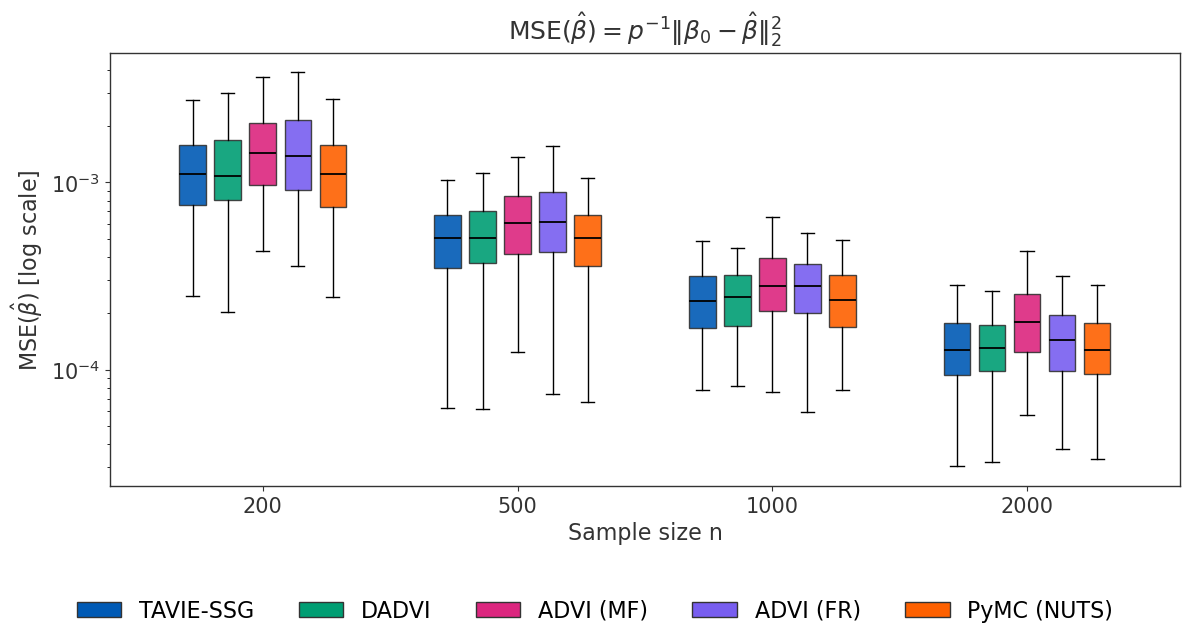

In [3]:
total_p = 9  # total_p = p + 1
p = 8  # <-- set this to whatever you used
path2 = f'results_compete/NegBin_metrics_multi_n_p_{p}.pkl'

metrics_df_2 = pd.read_pickle(path2)
sample_sizes = metrics_df_2['n']

mse_beta_TAVIE = metrics_df_2['mse_beta_TAVIE']
time_TAVIE = metrics_df_2['time_TAVIE']

mse_beta_DADVI = metrics_df_2['mse_beta_DADVI']
time_DADVI = metrics_df_2['time_DADVI']

mse_beta_ADVI_mf = metrics_df_2['mse_beta_ADVI_mf']
time_ADVI_mf = metrics_df_2['time_ADVI_mf']

mse_beta_ADVI_fr = metrics_df_2['mse_beta_ADVI_fr']
time_ADVI_fr = metrics_df_2['time_ADVI_fr']

mse_beta_NUTS = metrics_df_2['mse_beta_NUTS']
time_NUTS = metrics_df_2['time_NUTS']

methods = ['TAVIE', 'DADVI', 'ADVI MF', 'ADVI FR', 'NUTS']

runtime_arrays_n = [time_TAVIE, time_DADVI, time_ADVI_mf, time_ADVI_fr, time_NUTS]

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

methods = ['TAVIE-SSG', 'DADVI', 'ADVI (MF)', 'ADVI (FR)', 'PyMC (NUTS)']

# 5 red-ish tones, light → deep
colors = [
    "#005AB5",   # TAVIE-SSG  — vivid royal blue
    "#009E73",   # DADVI      — emerald green
    "#DC267F",   # ADVI (MF)  — vibrant magenta
    "#785EF0",   # ADVI (FR)  — electric violet
    "#FE6100",   # PyMC (NUTS)— vivid orange
]

n_sizes = len(sample_sizes)

# layout controls
M             = len(methods)
group_spacing = 2.4
method_step   = 0.33
box_width     = 0.25
centers       = np.arange(n_sizes) * group_spacing

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')
median_kws = dict(color='black', linewidth=1.3)

# ---- β MSE (log scale) ----
beta_arrays = [
    mse_beta_TAVIE,
    mse_beta_DADVI,
    mse_beta_ADVI_mf,
    mse_beta_ADVI_fr,
    mse_beta_NUTS,
]

for j, arr in enumerate(beta_arrays):
    # arr shape: (n_sizes, n_reps)
    data = [arr[i, :] for i in range(n_sizes)]
    positions = centers + (j - (M - 1) / 2) * method_step
    bp = ax.boxplot(
        data,
        positions=positions,
        widths=box_width,
        patch_artist=True,
        medianprops=median_kws,
        showfliers=False,
        whiskerprops=dict(linewidth=1.0),
        capprops=dict(linewidth=1.0),
    )
    for box in bp['boxes']:
        box.set(facecolor=colors[j], edgecolor='#333333', alpha=0.9)

ax.set_xticks(centers)
ax.set_xticklabels(sample_sizes, fontsize=15)
ax.set_yscale('log')
ax.set_xlabel('Sample size n', fontsize=16, color='#333333')
ax.set_ylabel(r'MSE($\hat{\beta}$) [log scale]', fontsize=16, color='#333333')
ax.set_title(r'$\mathrm{MSE}(\hat{\beta}) = p^{-1}\|\beta_0 - \hat{\beta}\|_{2}^{2}$', fontsize=18, color='#333333', pad=10)
ax.set_xlim(centers[0] - group_spacing * 0.6,
            centers[-1] + group_spacing * 0.6)

# style
ax.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_color('#333333')
    spine.set_linewidth(1.0)
ax.tick_params(axis='both', colors='#333333', labelsize=15)

# legend below
handles = [Patch(facecolor=colors[i], edgecolor='#333333', label=methods[i]) for i in range(M)]
fig.legend(
    handles=handles,
    loc='lower center',
    ncol=M,
    frameon=False,
    bbox_to_anchor=(0.5, -0.08),
    fontsize=16,
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.subplots_adjust(bottom=0.18)
fig.savefig(
    f'results_compete/plots/Neg-Bin_MSE_boxplots_multi_n_p_{p}.pdf',  # choose your preferred path/name
    dpi=300,
    bbox_inches='tight',   # ensures no clipping of labels/legend
    facecolor='white'      # preserves clean white background
)
plt.show()

### Figure 29 in Supplementary Materials

See: `results_compete/plots/Negbin_SW_boxplots_multi_n_p_8_logscale.pdf`.

Saved figure to: results_compete/plots/Negbin_SW_boxplots_multi_n_p_8_logscale.pdf


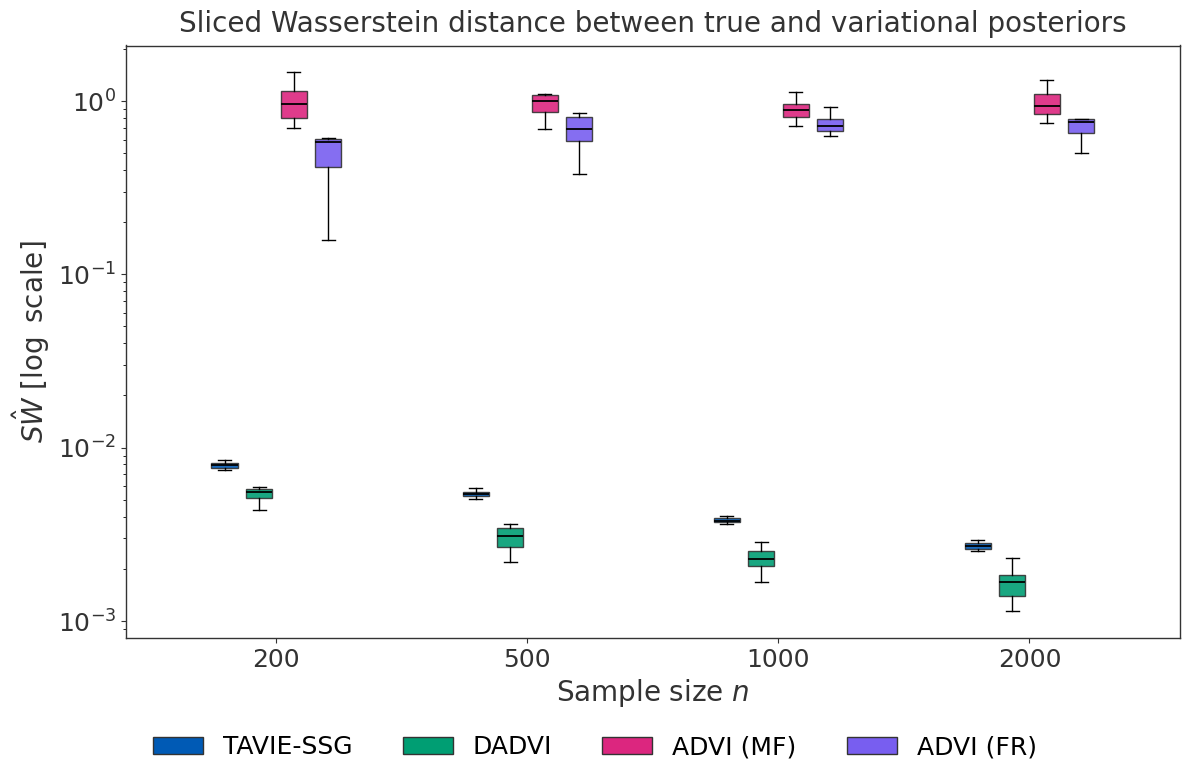

In [4]:
# ============================================================
# STYLED NEGATIVE-BINOMIAL SW BOXPLOT
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ------------------------------------------------------------
# Load saved Sliced Wasserstein results
# ------------------------------------------------------------

p = globals().get("p", 8)
alpha = globals().get("alpha", 1.0)
output_dir = globals().get("output_dir", "results_compete")

sw_results_path = os.path.join(
    output_dir,
    f"sw_negbin_compare_methods_alpha_{alpha}_p_{p}.csv"
)

if not os.path.exists(sw_results_path):
    raise FileNotFoundError(
        f"Could not find the saved SW results:\n{sw_results_path}\n"
        "Check p, alpha, and output_dir, or run the simulation cell first."
    )

results_df = pd.read_csv(sw_results_path)

# Columns containing the SW distance for each method
sw_columns = [
    "sw_TAVIE",
    "sw_DADVI",
    "sw_ADVI_mf",
    "sw_ADVI_fr",
]

required_columns = ["n", "rep", "alpha", *sw_columns]
missing_columns = set(required_columns).difference(results_df.columns)

if missing_columns:
    raise ValueError(
        f"{sw_results_path} is missing required columns: "
        f"{sorted(missing_columns)}"
    )

# Convert from wide to long format
plot_df = results_df.melt(
    id_vars=["n", "rep", "alpha"],
    value_vars=sw_columns,
    var_name="method",
    value_name="sliced_wasserstein"
)

# Assign display names
plot_df["method"] = plot_df["method"].map({
    "sw_TAVIE": "TAVIE-SSG",
    "sw_DADVI": "DADVI",
    "sw_ADVI_mf": "ADVI (MF)",
    "sw_ADVI_fr": "ADVI (FR)",
})

# ------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------

methods = [
    "TAVIE-SSG",
    "DADVI",
    "ADVI (MF)",
    "ADVI (FR)",
]

colors = [
    "#005AB5",   # TAVIE-SSG  — vivid royal blue
    "#009E73",   # DADVI      — emerald green
    "#DC267F",   # ADVI (MF)  — vibrant magenta
    "#785EF0",   # ADVI (FR)  — electric violet
]

# Obtain sample sizes directly from the loaded SW results
n_list = sorted(plot_df["n"].dropna().unique().tolist())
n_sizes = len(n_list)

M = len(methods)
group_spacing = 2.4
method_step = 0.33
box_width = 0.25

centers = np.arange(n_sizes) * group_spacing

fig, ax = plt.subplots(
    1,
    1,
    figsize=(12, 8),
    facecolor="white"
)

median_kws = {
    "color": "black",
    "linewidth": 1.3,
}

# ------------------------------------------------------------
# Global axis style
# ------------------------------------------------------------

ax.set_facecolor("white")

for spine in ax.spines.values():
    spine.set_color("#333333")
    spine.set_linewidth(1.0)

ax.tick_params(
    axis="both",
    colors="#333333",
    labelsize=18
)

# ------------------------------------------------------------
# Collect SW values by method and sample size
# ------------------------------------------------------------

sw_arrays = []

for method in methods:
    method_arrays = []

    for n in n_list:
        vals = plot_df.loc[
            (plot_df["n"] == n)
            & (plot_df["method"] == method),
            "sliced_wasserstein"
        ].dropna().to_numpy(dtype=float)

        # A logarithmic axis requires strictly positive values
        vals = vals[vals > 0]

        method_arrays.append(vals)

    sw_arrays.append(method_arrays)

# ------------------------------------------------------------
# Plot grouped boxplots
# ------------------------------------------------------------

for j, method_arrays in enumerate(sw_arrays):
    positions = (
        centers
        + (j - (M - 1) / 2) * method_step
    )

    bp = ax.boxplot(
        method_arrays,
        positions=positions,
        widths=box_width,
        patch_artist=True,
        medianprops=median_kws,
        showfliers=False,
        whiskerprops={"linewidth": 1.0},
        capprops={"linewidth": 1.0}
    )

    for box in bp["boxes"]:
        box.set(
            facecolor=colors[j],
            edgecolor="#333333",
            alpha=0.9
        )

# ------------------------------------------------------------
# Axis formatting
# ------------------------------------------------------------

ax.set_xticks(centers)
ax.set_xticklabels(n_list, fontsize=18)
ax.set_yscale("log")

ax.set_xlabel(
    r"Sample size $n$",
    fontsize=20,
    color="#333333"
)

ax.set_ylabel(
    r"$\hat{SW}$ [$\log$ scale]",
    fontsize=20,
    color="#333333"
)

ax.set_title(
    "Sliced Wasserstein distance between true and "
    "variational posteriors",
    fontsize=20,
    color="#333333",
    pad=10
)

ax.set_xlim(
    centers[0] - group_spacing * 0.6,
    centers[-1] + group_spacing * 0.6
)

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

handles = [
    Patch(
        facecolor=colors[i],
        edgecolor="#333333",
        label=methods[i]
    )
    for i in range(M)
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=M,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02),
    fontsize=18
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.subplots_adjust(bottom=0.16, top=0.90)

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

plots_dir = os.path.join(output_dir, "plots")
os.makedirs(plots_dir, exist_ok=True)

figure_path = os.path.join(
    plots_dir,
    f"Negbin_SW_boxplots_multi_n_p_{p}_logscale.pdf"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

print(f"Saved figure to: {figure_path}")

plt.show()

### Experiment E2: fixed $n=1000$ and $p\in \{4, 9, 16, 21\}$ (includes intercept)

Recording $p^{-1}\lVert \beta_0 - \hat{\beta}\rVert_{2}^{2}$. The results are stored in `results_compete/NegBin_metrics_multi_p_n_1000.pkl`.

In [ ]:
# ==== Experiment settings ====
n = 1000
total_p_values = [4, 9, 16, 21]  # total_p_values = p_values + 1
p_values   = [3, 8, 15, 20]
r = 10
num_reps   = 100

# Pre‐allocate storage
P = len(p_values)
mse_beta_TAVIE        = np.zeros((P, num_reps))
time_TAVIE            = np.zeros((P, num_reps))

mse_beta_DADVI        = np.zeros((P, num_reps))
time_DADVI            = np.zeros((P, num_reps))

mse_beta_NUTS        = np.zeros((P, num_reps))
time_NUTS            = np.zeros((P, num_reps))

mse_beta_ADVI_mf         = np.zeros((P, num_reps))
time_ADVI_mf             = np.zeros((P, num_reps))

mse_beta_ADVI_fr = np.zeros((P, num_reps))
time_ADVI_fr     = np.zeros((P, num_reps))

# ==== Main loops over p and replicates ====
for i, p in enumerate(p_values):
    # Prior covariance for BBVI full-cov
    Sigma_prior = np.eye(p + 1)

    # Initialize TAVIE model once for this p
    negbin_tavie_model = TAVIE_type_II(family="negbin", fit_intercept=True)

    # Draw a fixed "true" beta for this p
    beta_true = np.random.normal(loc=0.0, scale=0.5, size=p+1)

    for rep in trange(num_reps, desc=f"p={p}"):
        np.random.seed(rep)
        # Generate synthetic data
        X = np.random.normal(size=(n, p))
        X_bbvi = np.column_stack((np.ones(n), X))
        linear_term  = beta_true[0] + X @ beta_true[1:len(beta_true)] 
        probs = 1 / (1 + np.exp(-linear_term))
        y = np.random.negative_binomial(r, probs, size=n)

        # ---- TAVIE ----
        t0 = perf_counter()
        negbin_tavie_model.fit(X, y, r=r, verbose=False)
        time_TAVIE[i, rep] = perf_counter() - t0
        beta_est_TAVIE = negbin_tavie_model.get_TAVIE_means(verbose=False)
        mse_beta_TAVIE[i, rep] = np.mean((beta_est_TAVIE - beta_true)**2)

        # DADVI estimator
        negbin_dadvi_model = negbin_pymc_model(X_bbvi, y, r=r)
        t0 = perf_counter()
        negbin_dadvi_res = fit_pymc_dadvi_with_jax(negbin_dadvi_model, num_fixed_draws=30).get_posterior_means()
        time_DADVI[i, rep] = perf_counter() - t0
        beta_est_DADVI = negbin_dadvi_res['beta']
        mse_beta_DADVI[i, rep] = np.mean((beta_est_DADVI - beta_true)**2)
    
        # NUTS estimator
        t0 = perf_counter()
        negbin_nuts_res = fit_NUTS_negbin(negbin_dadvi_model)
        time_NUTS[i, rep] = perf_counter() - t0
        beta_est_NUTS = negbin_nuts_res['beta']
        mse_beta_NUTS[i, rep] = np.mean((beta_est_NUTS - beta_true)**2)

        # ADVI mean-field estimator
        t0 = perf_counter()
        res2 = BBVI_NegBin_patience_best(X_bbvi, y, r=r, lr=1e-3, tol=1e-9, patience=1e4, verbose=False)
        time_ADVI_mf[i, rep] = perf_counter() - t0
        beta_est_ADVI_mf = res2['beta_mean']
        mse_beta_ADVI_mf[i, rep] = np.mean((beta_est_ADVI_mf - beta_true)**2)
    
        # ADVI full-rank estimator
        t0 = perf_counter()
        res3 = BBVI_NegBin_fullcov_AdamW_best(X_bbvi, y, r=r, Sigma_prior=Sigma_prior, lr=1e-3, tol=1e-9, patience=1e4, verbose=False)
        time_ADVI_fr[i, rep] = perf_counter() - t0
        beta_est_ADVI_fr = res3['beta_mean']
        mse_beta_ADVI_fr[i, rep] = np.mean((beta_est_ADVI_fr - beta_true)**2)

        

# saving the metrics
import pickle

# collect everything into a single dict
metrics_df = {
    'p'            :      p_values,
    'n'            :      n,
    'mse_beta_TAVIE':     mse_beta_TAVIE,
    'time_TAVIE':         time_TAVIE,
    'mse_beta_ADVI_mf':      mse_beta_ADVI_mf,
    'time_ADVI_mf':          time_ADVI_mf,
    'mse_beta_ADVI_fr':      mse_beta_ADVI_fr,
    'time_ADVI_fr':          time_ADVI_fr,
    'mse_beta_DADVI':      mse_beta_DADVI,
    'time_DADVI':          time_DADVI,
    'mse_beta_NUTS':      mse_beta_NUTS,
    'time_NUTS':          time_NUTS,
}

# write to disk
with open(f'results_compete/NegBin_metrics_multi_p_n_{n}.pkl', 'wb') as f:
    pickle.dump(metrics_df, f, protocol=pickle.HIGHEST_PROTOCOL)

### Figure 30 in Supplementary Materials

See: `results_compete/plots/Neg-Bin_MSE_boxplots_multi_p_n_1000.pdf`

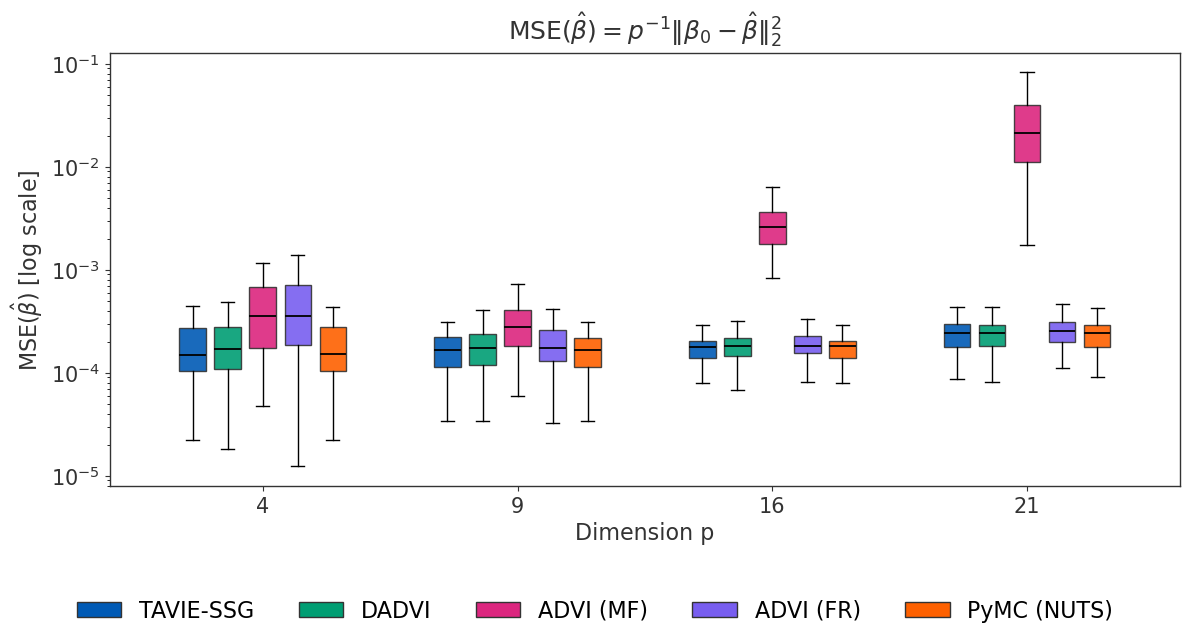

In [4]:
n = 1000
path3 = f'results_compete/NegBin_metrics_multi_p_n_{n}.pkl'

metrics_df_3 = pd.read_pickle(path3)
p_values = metrics_df_3['p']

mse_beta_TAVIE = metrics_df_3['mse_beta_TAVIE']
time_TAVIE = metrics_df_3['time_TAVIE']

mse_beta_DADVI = metrics_df_3['mse_beta_DADVI']
time_DADVI = metrics_df_3['time_DADVI']

mse_beta_ADVI_mf = metrics_df_3['mse_beta_ADVI_mf']
time_ADVI_mf = metrics_df_3['time_ADVI_mf']

mse_beta_ADVI_fr = metrics_df_3['mse_beta_ADVI_fr']
time_ADVI_fr = metrics_df_3['time_ADVI_fr']

mse_beta_NUTS = metrics_df_3['mse_beta_NUTS']
time_NUTS = metrics_df_3['time_NUTS']

methods = ['TAVIE', 'DADVI', 'ADVI MF', 'ADVI FR', 'NUTS']

runtime_arrays_p = [time_TAVIE, time_DADVI, time_ADVI_mf, time_ADVI_fr, time_NUTS]

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

methods = ['TAVIE-SSG', 'DADVI', 'ADVI (MF)', 'ADVI (FR)', 'PyMC (NUTS)']

# 5 red-ish tones, light → deep
colors = [
    "#005AB5",   # TAVIE-SSG  — vivid royal blue
    "#009E73",   # DADVI      — emerald green
    "#DC267F",   # ADVI (MF)  — vibrant magenta
    "#785EF0",   # ADVI (FR)  — electric violet
    "#FE6100",   # PyMC (NUTS)— vivid orange
]

p_sizes = len(p_values)

# layout controls
M             = len(methods)
group_spacing = 2.4
method_step   = 0.33
box_width     = 0.25
centers       = np.arange(p_sizes) * group_spacing

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')
median_kws = dict(color='black', linewidth=1.3)

# ---- β MSE (log scale) ----
beta_arrays = [
    mse_beta_TAVIE,
    mse_beta_DADVI,
    mse_beta_ADVI_mf,
    mse_beta_ADVI_fr,
    mse_beta_NUTS,
]

for j, arr in enumerate(beta_arrays):
    # arr shape: (n_sizes, n_reps)
    data = [arr[i, :] for i in range(p_sizes)]
    positions = centers + (j - (M - 1) / 2) * method_step
    bp = ax.boxplot(
        data,
        positions=positions,
        widths=box_width,
        patch_artist=True,
        medianprops=median_kws,
        showfliers=False,
        whiskerprops=dict(linewidth=1.0),
        capprops=dict(linewidth=1.0),
    )
    for box in bp['boxes']:
        box.set(facecolor=colors[j], edgecolor='#333333', alpha=0.9)

ax.set_xticks(centers)
ax.set_xticklabels(np.array(p_values)+1, fontsize=15)
ax.set_yscale('log')
ax.set_xlabel('Dimension p', fontsize=16, color='#333333')
ax.set_ylabel(r'MSE($\hat{\beta}$) [log scale]', fontsize=16, color='#333333')
ax.set_title(r'$\mathrm{MSE}(\hat{\beta}) = p^{-1}\|\beta_0 - \hat{\beta}\|^2_{2}$', fontsize=18, color='#333333', pad=10)
ax.set_xlim(centers[0] - group_spacing * 0.6,
            centers[-1] + group_spacing * 0.6)

# style
ax.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_color('#333333')
    spine.set_linewidth(1.0)
ax.tick_params(axis='both', colors='#333333', labelsize=15)

# legend below
handles = [Patch(facecolor=colors[i], edgecolor='#333333', label=methods[i]) for i in range(M)]
fig.legend(
    handles=handles,
    loc='lower center',
    ncol=M,
    frameon=False,
    bbox_to_anchor=(0.5, -0.08),
    fontsize=16,
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.subplots_adjust(bottom=0.18)
fig.savefig(
    f'results_compete/plots/Neg-Bin_MSE_boxplots_multi_p_n_{n}.pdf',  # choose your preferred path/name
    dpi=300,
    bbox_inches='tight',   # ensures no clipping of labels/legend
    facecolor='white'      # preserves clean white background
)
plt.show()

### Figure 31 in Supplementary Materials

See: `results_compete/plots/runtime_Negbin_multi_n_multi_p.pdf`

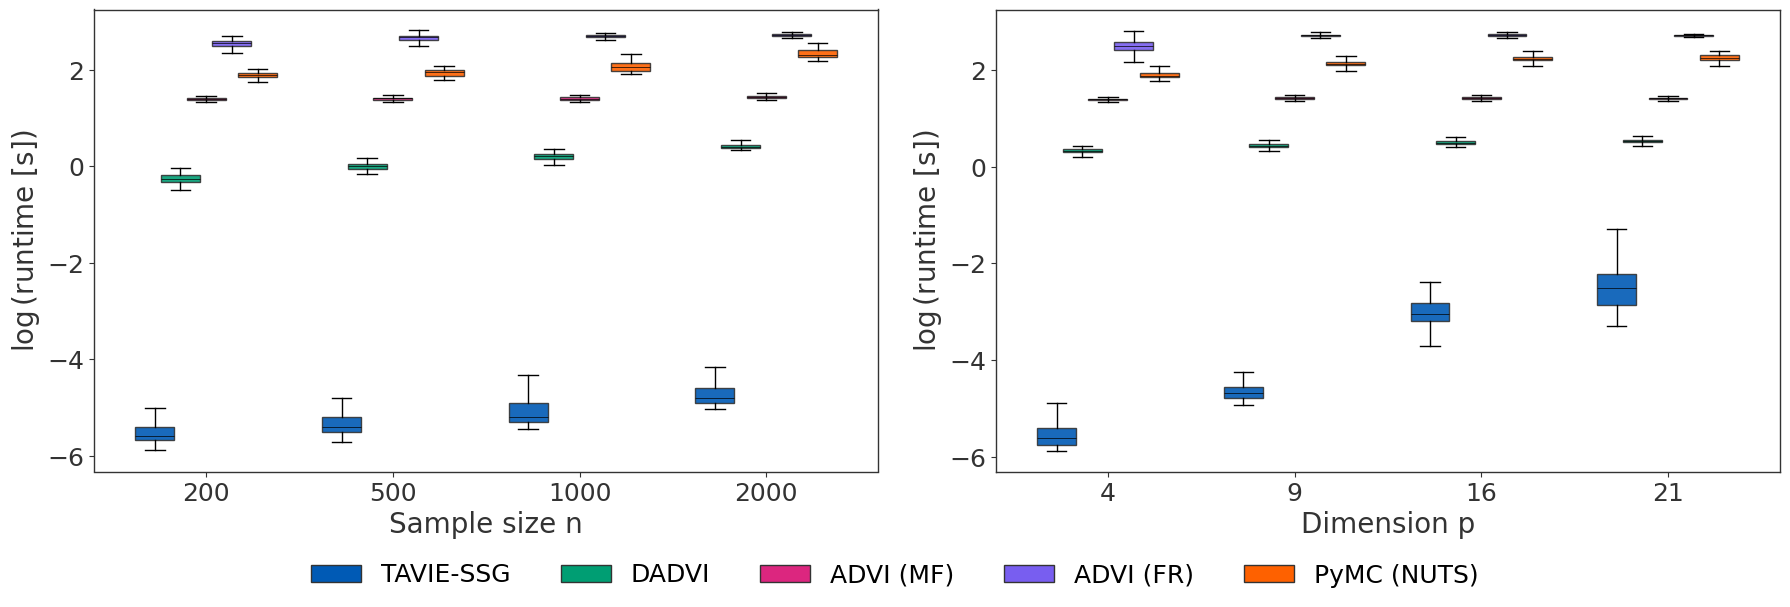

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

eps = 1e-16
methods = ['TAVIE-SSG', 'DADVI', 'ADVI (MF)', 'ADVI (FR)', 'PyMC (NUTS)']

colors_runtime = [
    "#005AB5",   # TAVIE-SSG  — vivid royal blue
    "#009E73",   # DADVI      — emerald green
    "#DC267F",   # ADVI (MF)  — vibrant magenta
    "#785EF0",   # ADVI (FR)  — electric violet
    "#FE6100",   # PyMC (NUTS)— vivid orange
]


# ----- Data arrays -----
#runtime_arrays_n = [time_TAVIE, time_DADVI, time_ADVI_mf, time_ADVI_fr, time_NUTS]
#runtime_arrays_p = [time_TAVIE, time_DADVI, time_ADVI_mf, time_ADVI_fr, time_NUTS]

n_sizes = len(sample_sizes)
p_sizes = len(p_values)
M = len(methods)
group_spacing = 2.4
method_step = 0.33
box_width = 0.50#0.25

# --- Create 1x2 figure ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor='white')
median_kws = dict(color='black', linewidth=0.5)

# ===============================================================
# Left panel: runtime vs sample size n
# ===============================================================
ax = axes[0]
centers = np.arange(n_sizes) * group_spacing

for j, arr in enumerate(runtime_arrays_n):
    data = [np.log(np.clip(arr[i, :], eps, None)) for i in range(n_sizes)]
    positions = centers + (j - (M - 1) / 2) * method_step
    bp = ax.boxplot(
        data, positions=positions, widths=box_width, patch_artist=True,
        medianprops=median_kws, showfliers=False,
        whiskerprops=dict(linewidth=1.0), capprops=dict(linewidth=1.0)
    )
    for box in bp['boxes']:
        box.set(facecolor=colors_runtime[j], edgecolor='#333333', alpha=0.9)

ax.set_xticks(centers)
ax.set_xticklabels(sample_sizes, fontsize=18)
ax.set_xlabel('Sample size n', fontsize=20, color='#333333')
ax.set_ylabel(r'$\log$(runtime [s])', fontsize=20, color='#333333')
ax.set_xlim(centers[0] - group_spacing * 0.6, centers[-1] + group_spacing * 0.6)
ax.tick_params(axis='both', colors='#333333', labelsize=18)
for spine in ax.spines.values():
    spine.set_color('#333333'); spine.set_linewidth(1.0)

# ===============================================================
# Right panel: runtime vs dimension p
# ===============================================================
ax = axes[1]
centers = np.arange(p_sizes) * group_spacing

for j, arr in enumerate(runtime_arrays_p):
    data = [np.log(np.clip(arr[i, :], eps, None)) for i in range(p_sizes)]
    positions = centers + (j - (M - 1) / 2) * method_step
    bp = ax.boxplot(
        data, positions=positions, widths=box_width, patch_artist=True,
        medianprops=median_kws, showfliers=False,
        whiskerprops=dict(linewidth=1.0), capprops=dict(linewidth=1.0)
    )
    for box in bp['boxes']:
        box.set(facecolor=colors_runtime[j], edgecolor='#333333', alpha=0.9)

ax.set_xticks(centers)
ax.set_xticklabels(np.array(p_values)+1, fontsize=18)
ax.set_xlabel('Dimension p', fontsize=20, color='#333333')
ax.set_ylabel(r'$\log$(runtime [s])', fontsize=20, color='#333333')
ax.set_xlim(centers[0] - group_spacing * 0.6, centers[-1] + group_spacing * 0.6)
ax.tick_params(axis='both', colors='#333333', labelsize=18)
for spine in ax.spines.values():
    spine.set_color('#333333'); spine.set_linewidth(1.0)

# ===============================================================
# Common legend (below both panels)
# ===============================================================
handles = [Patch(facecolor=colors_runtime[i], edgecolor='#333333', label=methods[i])
           for i in range(M)]
fig.legend(handles=handles, loc='lower center', ncol=M, frameon=False,
           fontsize=18, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout(rect=[0, 0.05, 1, 1])
fig.subplots_adjust(wspace=0.15, bottom=0.15, top=0.92)

fig.savefig('results_compete/plots/runtime_Negbin_multi_n_multi_p.pdf',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


### ELBO plots for TAVIE-SSG, ADVI (MF), and ADVI (FR): Figure 32 in Supplementary Section M.2

See: `results_compete/plots/NegBin_ELBO_n_1000_p_8.pdf`

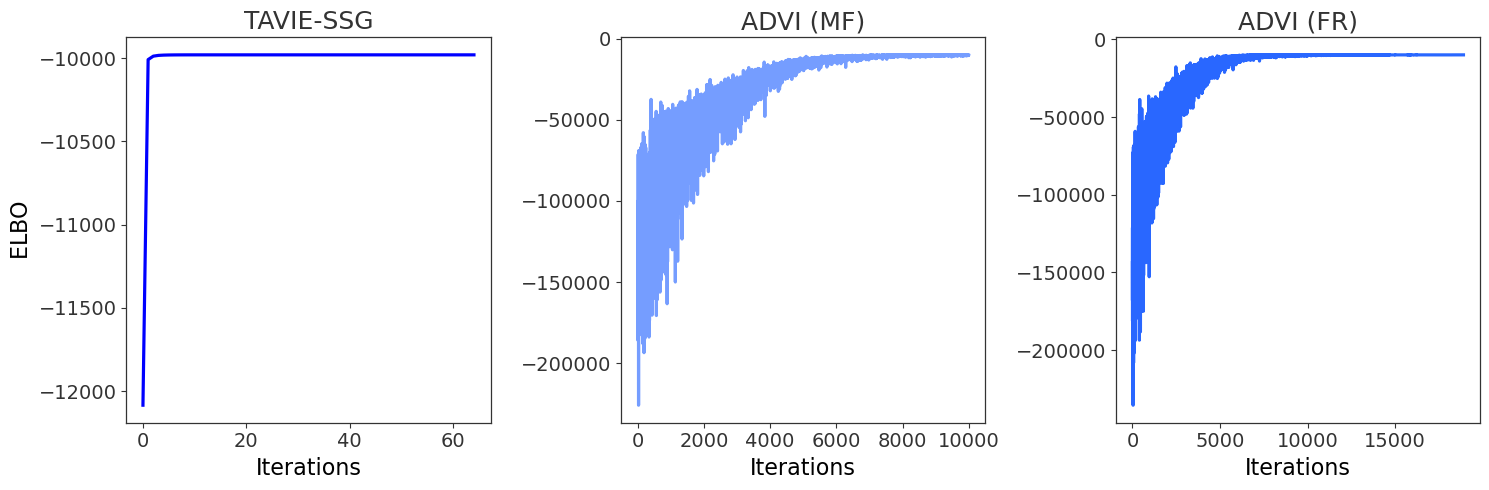

In [ ]:
# ==== Experiment settings ====
total_p = 9  # total_p = p + 1
p = 8
num_reps = 100
r = 10
n = 1000     # <-- your various n’s here

# True beta vector
beta_true = np.random.normal(loc=0.0, scale=0.5, size=p+1)

# Prior for full‐cov BBVI
Sigma_prior = np.eye(p + 1)

# TAVIE model initialization
negbin_tavie_model = TAVIE_type_II(family="negbin", fit_intercept=True)

X = np.random.normal(size=(n, p))
X_bbvi = np.column_stack((np.ones(n), X))
linear_term  = beta_true[0] + X @ beta_true[1:len(beta_true)] 
probs = 1 / (1 + np.exp(-linear_term))
y = np.random.negative_binomial(r, probs, size=n)

# ---- TAVIE ----
negbin_tavie_model.fit(X, y, r=r, verbose=False)

# ADVI mean-field estimator
res2 = BBVI_NegBin_patience_best(X_bbvi, y, r=r, lr=1e-3, tol=1e-9, patience=1e4, verbose=False)
    
# ADVI full-rank estimator
res3 = BBVI_NegBin_fullcov_AdamW_best(X_bbvi, y, r=r, Sigma_prior=Sigma_prior, lr=1e-3, tol=1e-9, patience=1e4, verbose=False)

tavie_elbo = negbin_tavie_model.get_elbo()
advi_mf_elbo = res2['elbo_hist']
advi_fr_elbo = res3['elbo_hist']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='white')
colors = [
    'blue',  # bright aqua
    '#759DFF',  # turquoise blue
    '#2967FF'   # strong deep blue
]
axes[0].plot(tavie_elbo, color=colors[0], linewidth=2.3)
axes[0].set_title(r'TAVIE-SSG', fontsize=18, color='#333333')
axes[0].set_xlabel('Iterations', fontsize=16)
axes[0].set_ylabel(r'$\mathsf{ELBO}$', fontsize=16)

axes[1].plot(advi_mf_elbo, color=colors[1], linewidth=2.3)
axes[1].set_title(r'ADVI (MF)', fontsize=18, color='#333333')
axes[1].set_xlabel('Iterations', fontsize=16)

axes[2].plot(advi_fr_elbo, color=colors[2], linewidth=2.3)
axes[2].set_title(r'ADVI (FR)', fontsize=18, color='#333333')
axes[2].set_xlabel('Iterations', fontsize=16)

# --- Shared styling ---
for ax in axes:
    #ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)
    for spine in ax.spines.values():
        spine.set_color('#333333')
        spine.set_linewidth(0.9)
    ax.tick_params(axis='both', labelsize=14, colors='#333333')

plt.tight_layout()
#fig.suptitle(r'$\mathsf{ELBO}$ Convergence Trajectories', fontsize=17, color='#333333', y=1.03)

# Save high-resolution figure
fig.savefig(f'results_compete/plots/NegBin_ELBO_n_{n}_p_{p}.pdf',
           dpi=300, bbox_inches='tight', facecolor='white')
plt.show()